# Coagulation Kernel Tests

The Smoluchowski equation has analytical solutions for the constant, linear and product kernel and we test `mcdust` against the solutions for these kernels. To run the simulations use the following commands. 
For the constant kernel,

`make kerneltest SETUP_FILE=kernel_constant`

For the linear kernel,

`make kerneltest SETUP_FILE=kernel_linear`

For the product kernel,

`make kerneltest SETUP_FILE=kernel_product`

To remove the compilation

`make clean SETUP_FILE=kernel_linear` 

(replace `kernel_linear` with the respective kernel setup directory for other kernels.

We refer the reader to Drazkowska et al. 2013 for more details of the benchmark of the monte carlo method implemented in `mcdust` 


In [1]:
import matplotlib.pyplot as plt
import os as os
import numpy as np
import h5py
from scipy.special import gammaln

In [56]:
# The solutions from Tanaka & Nakazawa 1994

def analytical_constant_kernel(t, m, a=1.):
    """Function to compute the analytical solution for the constant kernel

        Args:
            t: dimensionless time
            m: mass grid
            a: constant for the constant coagulation kernel
        Returns:
            N*m**2: mass density for the given mass grid and time
    """         
    m0 = m[0]
    N0 = 1./m0
    N = N0/m0*4./(a*N0*t)**2 *np.exp((1.-m/m0)*2/(a*N0*t))
    return N*m**2
    
def analytical_linear_kernel(t,m,a=0.5):
    """Function to compute the analytical solution for the linear kernel

        Args:
            t: dimensionless time
            m: mass grid
            a: prefactor for the linear coagulation kernel
        Returns:
            N*m**2: mass density for the given mass grid and time
    """       
    m0 = m[0]
    N0 = 1./m0**2
    g = np.exp(-a*t)
    k = (m / m0)
    
    # compute it with logarithm because large numbers give numerical problems
    logN = np.log(N0*g) - k*(1.-g) + (k-1.)*np.log(k*(1.-g)) - gammaln(k+1.)
    N = np.exp(logN) 
    return N*m**2

def analytical_product_kernel(t, m):
    """Function to compute the analytical solution for the product kernel

        Args:
            t: dimensionless time
            m: mass grid
        Returns:
            N*m**2: mass density for the given mass grid and time
    """   
    # compute it with logarithm because large numbers give numerical problems
    logN = (m-1)*np.log(m*t) - m*t - gammaln(m+1.) - np.log(m)
    N = np.exp(logN) 
    return N*m**2

def analytical_fragmentation_sol(t,m, gamma=1.e4):
    """Function to compute the analytical solution for the distribution of fragmentes
        Taken from Lombart et al 2024

        Args:
            t: dimensionless time
            m: mass grid
        gamma: size distribution parameter 
        Returns:
            N*m**2: mass density for the given mass grid and time
    """   
    N0 = np.exp(-m)
    
    loga = gamma*t
    a = np.array(np.exp(loga),dtype=np.float128)
    b = np.exp(-1*gamma*m)
    c = gamma*( a - 1) * b
    d = (a-1)/gamma
    N = (N0 + c)/(1+d)
    return N*m**2

In [25]:
def read(type='linear',repeat = 5,nmbins=250):
    """Function to read the simulation data for the kernel tests

        Args:
            type: the kernel type used in the simulation, defaults to linear
            repeat: number of times the simulation is repeated
            nmbins: number of mass bins to build the mass grid
        Returns:
            result: a dict that containts the mass density, m2fm, values of the mass grid mgrid_cents, the output times t_arr
        """   
    if type == 'constant':
        filedir = 'kernel_constant'
        ntime = 6
        timearr = [1,10,100,1000,10000,100000]
    elif type == 'product':
        filedir = 'kernel_product'
        ntime = 3
        timearr = [0.4,0.7,0.9]
    elif type == 'frag':
        filedir = 'fragtest'
        ntime = 10
        timearr = np.linspace(0,3e-3,10)
    else:
        filedir = 'kernel_linear'
        ntime = 5
        timearr = [4,8,12,16,20]
    m2fm = np.zeros((nmbins,ntime,repeat))
    mgrid_wall = np.zeros((nmbins+1,ntime,repeat))
    for i in range(repeat):
        
        for j in range(ntime):
            #fname = os.path.join('../outputs/',filedir+str(i+1),'out-00'+str(j+1)+'.dat')
            fname = os.path.join('../outputs/',filedir+str(i+1),f'out-{j+1:03d}.dat')   
            data = np.loadtxt(fname)
            mgrid = data[:,0]
            m2fm[:,j,i] = data[:,1]
    result = {
        "m2fm" :  m2fm,
        "mgrid_cents" : mgrid,
        "tarr" : timearr
    }
    return result
        

In [4]:
def plot(result,type='linear'):
    """Function to produce plot of mass density to compare the analytical kernel solutions with the simulations

        Args:
            type: the kernel type used in the simulation, defaults to linear
    """   
    start = 1
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    f,ax = plt.subplots()
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_ylim(10**-2,2)
    ax.set_ylabel('$m^2$f(m)')
    ax.set_xlabel('m')
    if (type == 'constant'):
       ax.set_xlim(1,10**6)
       ax.set_ylim(10**-2,2)
    elif (type == 'product'):
       ax.set_xlim(1,10**3)
       ax.set_ylim(10**-2,1)
    else:
       ax.set_xlim(1,10**10)
       ax.set_ylim(10**-2,4e-1)
    c = colors[0 % len(colors)]
    ax.scatter(result["mgrid_cents"][start:], 
                 np.mean(result["m2fm"][start:, 0,:], axis=1),
                    marker='o',s=4, c='k',label='mcdust')
    if type == 'constant':
       ax.plot(result["mgrid_cents"],analytical_constant_kernel(result['tarr'][0], result["mgrid_cents"],a=1),
                 c='k', ls='--',label='analytical')
    elif type == "product":
       ax.plot(result["mgrid_cents"],analytical_product_kernel(result['tarr'][0], result["mgrid_cents"]),
                 c='k', ls='--',label='analytical')
    else:
       ax.plot(result["mgrid_cents"],analytical_linear_kernel(result['tarr'][0], result["mgrid_cents"],a=0.5),
                 c='k', ls='--',label='analytical')
    for it, time in enumerate(result["tarr"]):
       c = colors[it % len(colors)]
       ax.errorbar(result["mgrid_cents"][start:], 
                     np.mean(result["m2fm"][start:, it,:], axis=1),
                     yerr=np.std(result["m2fm"][start:, it, :], axis=1),
                     fmt='none', marker='.', c=c, capsize=3, ls=None)
       ax.scatter(result["mgrid_cents"][start:], 
                     np.mean(result["m2fm"][start:, it,:], axis=1),
                     marker='o',s=3, c=c)
       if type == 'constant':
           ax.plot(result["mgrid_cents"],analytical_constant_kernel(time, result["mgrid_cents"],a=1),
                 c=c, ls='--')
       elif type == "product":
           ax.plot(result["mgrid_cents"],analytical_product_kernel(time, result["mgrid_cents"]),
                 c=c, ls='--')
       else:
           ax.plot(result["mgrid_cents"],analytical_linear_kernel(time, result["mgrid_cents"],a=0.5),
                 c=c, ls='--')
       ax.legend()

## Constant Kernel


$$
K (m,m')= 1.
$$

From the figure below it can be seen that the Representative particle approach does not have the issue of artifical particle growth

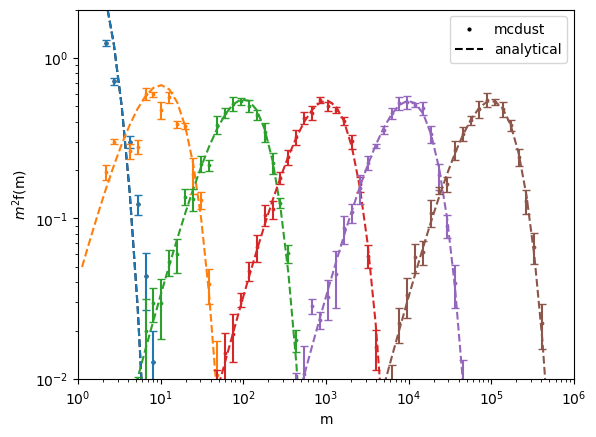

In [5]:
sim = read(type='constant')
plot(sim,type='constant')

## Linear kernel

$$
K(m,m') = 0.5(m_1 + m_2)
$$


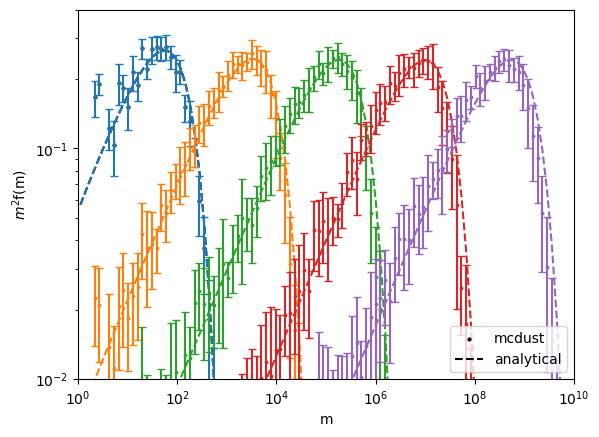

In [6]:
sim = read(type='linear',repeat=10)
plot(sim,type='linear')

## Product Kernel

$$
K(m,m') = m_1 m_2
$$

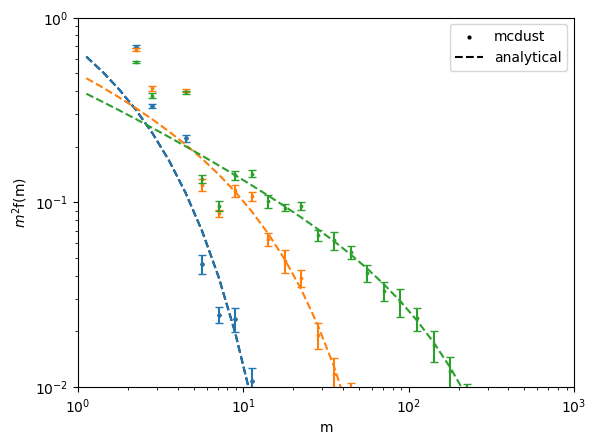

In [55]:
sim = read(type='product',repeat=10)
plot(sim,type='product')

## Fragmentation test

We test the fragmentation distribution with the test described in [Lombart et al. 2024](https://ui.adsabs.harvard.edu/abs/2024MNRAS.533.4410L/abstract).

The number density per mass bin after fragmentation is taken to be, $n(m;m_1) = \gamma^2(m_1)e^{-\gamma m}$ where $m_1$ is the sum of the masses of the colliding particles and $\gamma = 1e3$. This is the form that has an analytical solution given by,

$$
N(m,t) = \frac{N(m,0) + \gamma(e^{\gamma t} -1)e^{-\gamma m}}{1 + \frac{\gamma(e^{\gamma t} -1)}{\gamma}}
$$

where $N(m,0) = me^{-m}$

To run this use the command

`make kerneltest SETUP_FILE=fragtest`

`./test2 setups/fragtest/setup.par`

In [86]:
sim = read(type='frag',repeat=1)

In [82]:
def plot_frag_dist(sim, time):
    """Function to plot the distribution of fragments

        Args:
            sim(dict): simulation data
            time: dimensionless time 
        Returns:
            N*m**2: mass density for the given mass grid and time
    """   
    it = np.array(sim['tarr']).searchsorted(time)
    f,ax = plt.subplots()
    ax.scatter(sim["mgrid_cents"][start:], 
                     np.mean(sim["m2fm"][start:, it,:], axis=1),
                     marker='o', c='k',s=3,label='mcdust')
    ax.plot(sim["mgrid_cents"][start:],analytical_fragmentation_sol(sim['tarr'][it], sim["mgrid_cents"][start:],gamma=1e3),
                 c='b', ls='--',label='analytical')
    ax.set_xlim(1.e-6,1e3)
    ax.set_ylim(1e-22,1e4)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('m')
    ax.set_ylabel('$m^2$f(m)')
    ax.set_title('t = {:e}'.format(sim['tarr'][it]))
    ax.legend()

Now we follow the evolution of the distribution. Shown blow are the plots at t = 0, $t = 1.6 \times 10^{-3}$ and $t = 3 \times 10^{-3}$. This simulation was run with 50000 particles as an example. 

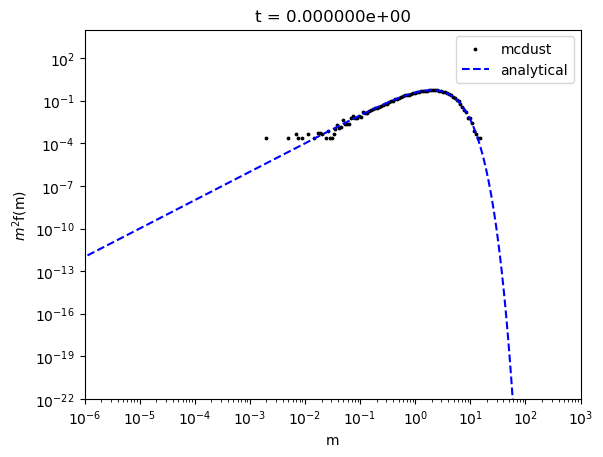

In [90]:
time = 0
plot_frag_dist(sim,0)

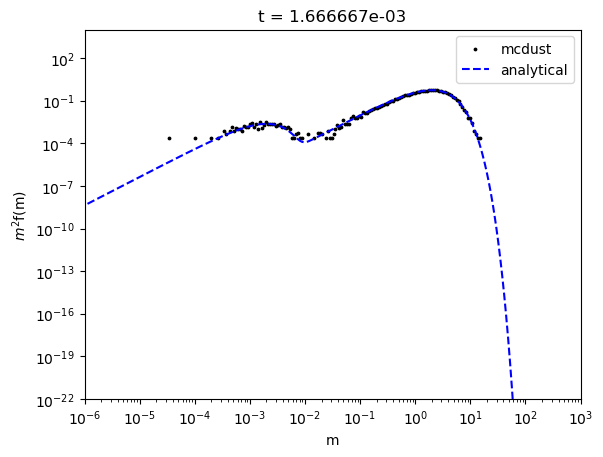

In [91]:
time = 1.66e-3
plot_frag_dist(sim,time)

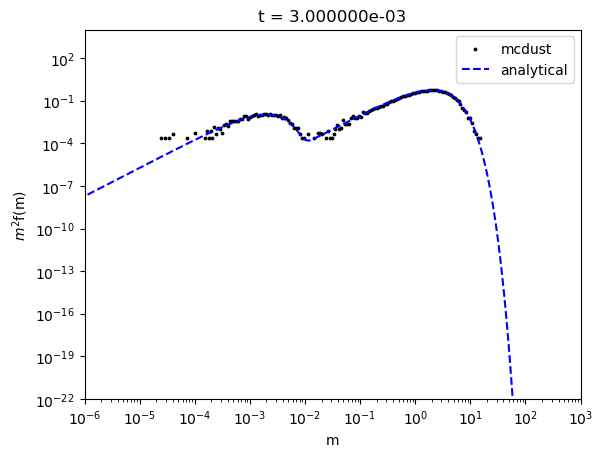

In [92]:
time = 3.e-3
plot_frag_dist(sim,time)